## CNN regression

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [2]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU NVIDIA A40


## Dataset: UTK Face

See here: https://susanqq.github.io/UTKFace/

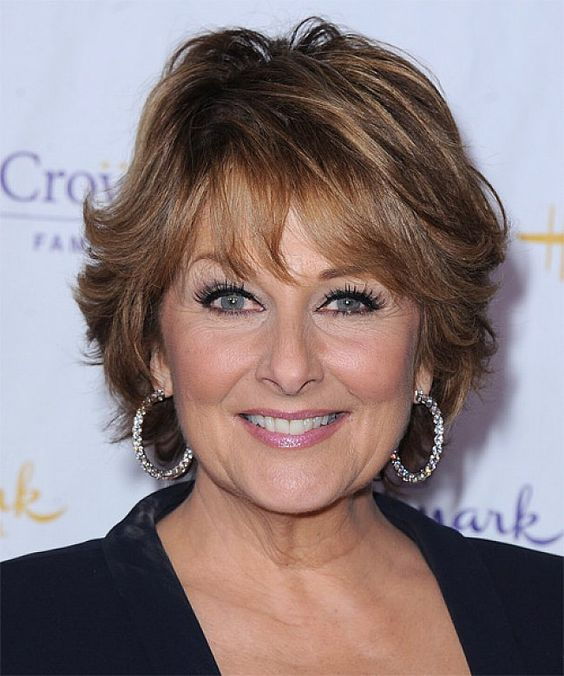

In [3]:
import os
from PIL import Image

path = '/home/jcolen/data10/utk-face/UTKface_inthewild'
image_files = os.listdir(path)

img = Image.open(os.path.join(path, image_files[0]))
img

In [4]:
from torch.utils.data import Dataset
class UTKFaceDataset(Dataset):
    """ Custom dataset class to load in UTK Face dataset elements
        Files have the name format [age]_[gender]_[race]_[date&time].jpg
    """
    def __init__(self, root='/home/jcolen/data10/utk-face/UTKface_inthewild', transform=None):
        self.root = root
        self.image_files = [f for f in os.listdir(self.root) if f.endswith('.jpg')]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_file = self.image_files[idx]
        image = Image.open(os.path.join(self.root, image_file))
        if image.mode != 'RGB': 
            image = image.convert('RGB')
            
        # File name contains the target
        age = int(image_file.split('_')[0])

        if self.transform:
            image, age = self.transform(image, age)

        return image, torch.tensor(age, dtype=torch.float32)

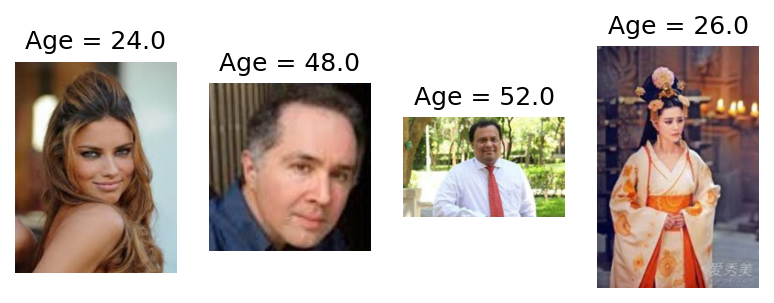

In [5]:
dataset = UTKFaceDataset()

fig, ax = plt.subplots(1, 4)
for ii in range(4):
    idx = np.random.choice(len(dataset))
    img, age = dataset[idx]
    ax[ii].imshow(img)
    ax[ii].set_title(f'Age = {age:.1f}')
    ax[ii].axis('off')

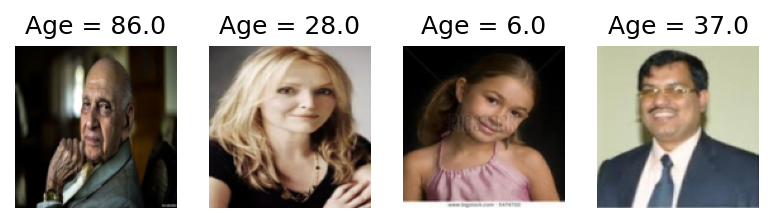

In [6]:
from torchvision.transforms import v2
transform = v2.Compose([
    v2.ToImage(),
    v2.Resize([128, 128]),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = UTKFaceDataset(transform=transform)

fig, ax = plt.subplots(1, 4)
for ii in range(4):
    idx = np.random.choice(len(dataset))
    img, age = dataset[idx]
    ax[ii].imshow(img.permute(1, 2, 0) * 0.5 + 0.5)
    ax[ii].set_title(f'Age = {age:.1f}')
    ax[ii].axis('off')

In [7]:
from torch.utils.data import random_split
train_dataset, val_dataset, test_dataset = random_split(dataset, lengths=[0.6, 0.2, 0.2])
print(len(train_dataset), len(val_dataset), len(test_dataset))

14464 4821 4821


## CNN implementation

In [69]:
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, **conv_kwargs):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, **conv_kwargs)
        self.conv2 = nn.Conv2d(c_out, c_out, **conv_kwargs)
        self.conv3 = nn.Conv2d(c_out, c_out, **conv_kwargs)
    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        
        y = self.conv2(x)
        y = F.relu(y)
        y = self.conv3(y)
        y = F.relu(y)
        y = x + y # Skip connection
        
        y = F.max_pool2d(y, 2)
        return y

class CNN_Regression(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = ConvBlock(3, 32, kernel_size=3, padding='same')
        self.conv2 = ConvBlock(32, 64, kernel_size=3, padding='same')
        self.conv3 = ConvBlock(64, 128, kernel_size=3, padding='same')
        self.conv4 = ConvBlock(128, 256, kernel_size=3, padding='same')

        # I have a lot of options in what I do here
        # Global average pooling, big linear layer, some compromise to that?

        # Model input is [3, 128, 128]
        # After conv4 it will be [256, 128/16, 128/16] = [256, 8, 8]
        # Suppose I flatten this into a big FC layer?
        
        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(512, 1)

    def forward(self, x):
        # x has shape [B, 3, H, W]
        x = self.conv1(x) #[B, 32, H/2, W/2]
        x = self.conv2(x) #[B, 64, H/4, W/4]
        x = self.conv3(x) #[B, 128, H/8, W/8]
        x = self.conv4(x) #[B, 256, H/16, W/16]

        # Spatial average pooling
        # x = x.mean(dim=(-2, -1))

        # Flattening (most costly)
        x = x.reshape([-1, 256*8*8])

        # Consider transposing the data
        
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = F.relu(x) # Apply relu to ensure non-negative age predictions
        return x        

In [70]:
model = CNN_Regression().to(device)

img, age = dataset[0]
pred = model(img.to(device))
print(f'Model makes prediction which is {pred}')

num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CNN has {num_trainable_params} trainable parameters')

model

Model makes prediction which is tensor([[0.]], device='cuda:0', grad_fn=<ReluBackward0>)
CNN has 10345729 trainable parameters


CNN_Regression(
  (conv1): ConvBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  )
  (conv2): ConvBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  )
  (conv3): ConvBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  )
  (conv4): ConvBlock(
    (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv3): Conv2d(256, 256,

## Model training

In [94]:
from tqdm import tqdm
def train(model, optimizer, loss_func, train_dataset, val_dataset, batch_size=32, num_epochs=10, num_workers=4):
    model = model.to(device)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True, pin_memory=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False, pin_memory=True)

    train_loss = []
    train_mad = []
    val_loss = []
    val_mad = []

    for epoch in range(num_epochs):
        model.train()
        train_loss_ = 0.
        train_mad_ = 0.
        for xb, yb in tqdm(train_loader, leave=False):
            optimizer.zero_grad()
            
            xb = xb.to(device)
            yb = yb.to(device).unsqueeze(1)
            y_pred = model(xb)
            
            loss = loss_func(y_pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss_ += loss.item() * yb.shape[0]
            try:
                train_mad_ += F.l1_loss(y_pred, yb, reduction='sum').item()
            except:
                train_mad_ += F.l1_loss(y_pred[0], yb, reduction='sum').item()
            
        train_loss.append(train_loss_ / len(train_loader.dataset))
        train_mad.append(train_mad_ / len(train_loader.dataset))

        model.eval()
        with torch.no_grad():
            val_loss_ = 0.
            val_mad_ = 0.
            for xb, yb in tqdm(val_loader, leave=False):
                
                xb = xb.to(device)
                yb = yb.to(device).unsqueeze(1)
                y_pred = model(xb)
                
                loss = loss_func(y_pred, yb)
                val_loss_ += loss.item() * yb.shape[0]
                try:
                    val_mad_ += F.l1_loss(y_pred, yb, reduction='sum').item()
                except:
                    val_mad_ += F.l1_loss(y_pred[0], yb, reduction='sum').item()
            val_loss.append(val_loss_ / len(val_loader.dataset))
            val_mad.append(val_mad_ / len(val_loader.dataset))

        print(f'Epoch {epoch+1} | '
              f'Train loss { train_loss[-1]:.3f} | '
              f'Train MAD { train_mad[-1]:.3f} years | '
              f'Val loss { val_loss[-1]:.3f} | '
              f'Val MAD { val_mad[-1]:.3f} years '
        )

        # Consider early stopping
        # Consider learning rate scheduling

    return train_loss, train_mad, val_loss, val_mad

In [78]:
model = CNN_Regression()
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss, train_mad, val_loss, val_mad = train(
    model, optimizer, loss, train_dataset, val_dataset,
    batch_size=32, num_epochs=20, num_workers=4)

Epoch 1 | Train loss 505.454 | Train MAD 16.237 years | Val loss 370.403 | Val MAD 14.382 years 


Epoch 2 | Train loss 362.456 | Train MAD 14.660 years | Val loss 337.849 | Val MAD 14.007 years 


Epoch 3 | Train loss 318.760 | Train MAD 13.651 years | Val loss 289.845 | Val MAD 12.895 years 


Epoch 4 | Train loss 275.983 | Train MAD 12.579 years | Val loss 250.010 | Val MAD 11.921 years 


Epoch 5 | Train loss 245.903 | Train MAD 11.610 years | Val loss 227.777 | Val MAD 11.223 years 


...

Epoch 16 | Train loss 81.129 | Train MAD 6.744 years | Val loss 198.513 | Val MAD 9.856 years 


Epoch 17 | Train loss 77.054 | Train MAD 6.534 years | Val loss 196.229 | Val MAD 9.897 years 


Epoch 18 | Train loss 64.292 | Train MAD 6.001 years | Val loss 190.055 | Val MAD 9.932 years 


Epoch 19 | Train loss 60.449 | Train MAD 5.828 years | Val loss 192.994 | Val MAD 9.932 years 


Epoch 20 | Train loss 55.511 | Train MAD 5.554 years | Val loss 202.518 | Val MAD 10.063 years 


In [83]:
train_mad = [t.item() for t in train_mad]
val_mad = [t.item() for t in val_mad]

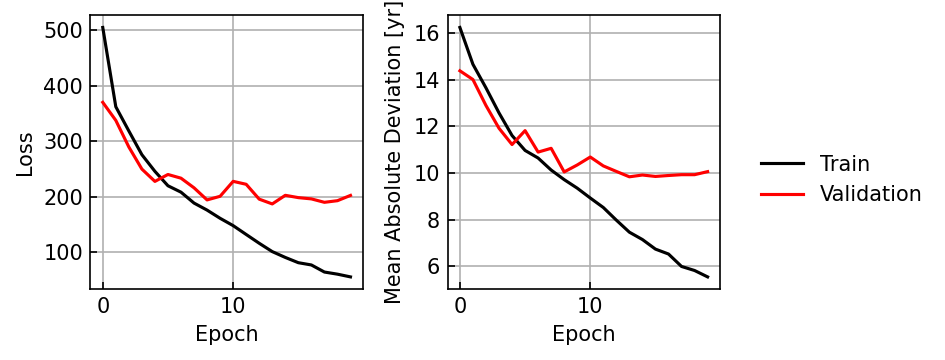

In [84]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

ax[0].plot(train_loss, color='black', label='Train')
ax[0].plot(val_loss, color='red', label='Validation')
ax[0].set(xlabel='Epoch', ylabel='Loss')

ax[1].plot(train_mad, color='black', label='Train')
ax[1].plot(val_mad, color='red', label='Validation')
ax[1].set(xlabel='Epoch', ylabel='Mean Absolute Deviation [yr]')

fig.legend(*ax[1].get_legend_handles_labels(), 
           loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

plt.tight_layout()

## Evaluate on testing dataset

In [85]:
y_true, y_pred = [], []
model.eval()

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)
with torch.no_grad():
    for xb, yb in tqdm(test_loader):
        yp = model(xb.to(device))
        y_true.append(yb.numpy())
        y_pred.append(yp.squeeze().cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
print(y_true.shape, y_pred.shape)

100%|██████████| 151/151 [00:15<00:00,  9.83it/s]

(4821,) (4821,)


Mean absolute difference: 9.7 yrs


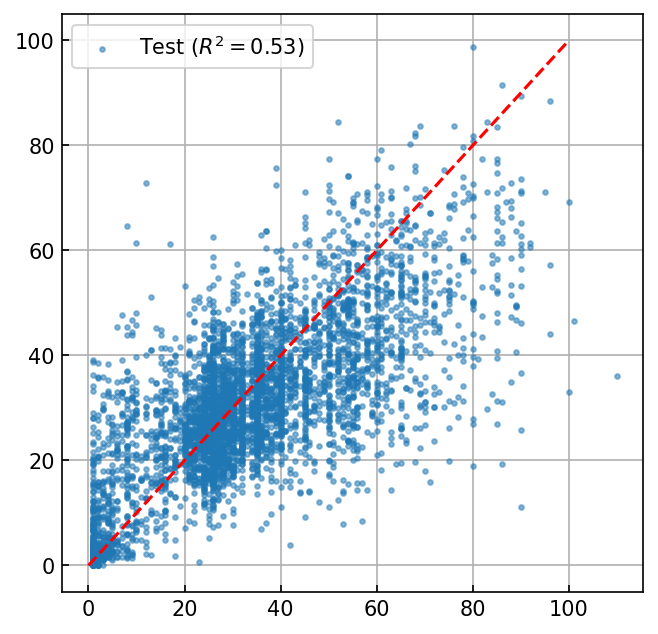

In [86]:
from sklearn.metrics import r2_score
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(y_true, y_pred, s=5, alpha=0.5, label=f'Test ($R^2 = {r2_score(y_true, y_pred):.2f}$)')
ax.plot([0,100], [0, 100], color='red', linestyle='--')
ax.legend();

print(f'Mean absolute difference: {np.mean(np.abs(y_true - y_pred)):.1f} yrs')

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ii, ax in enumerate(axes.flatten()):
    x, y = test_dataset[ii]
    with torch.no_grad():
        yp = model(x.to(device)[None]).squeeze().item()
    ax.imshow(0.5 * (x.cpu().permute(1, 2, 0) + 1)) #Denormalize images
    ax.set_title(f'True age: {y:.1f} yrs\nPred age: {yp:.1f}')
    ax.axis('off')

plt.tight_layout()

## Playing around a bit

In [98]:
import torch.nn as nn
import torch.nn.functional as F

class CNN_Regression(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = ConvBlock(3, 32, kernel_size=3, padding='same')
        self.conv2 = ConvBlock(32, 64, kernel_size=3, padding='same')
        self.conv3 = ConvBlock(64, 128, kernel_size=3, padding='same')
        self.conv4 = ConvBlock(128, 256, kernel_size=3, padding='same')
        
        self.fc1 = nn.Linear(256, 512)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        # x has shape [B, 3, H, W]
        x = self.conv1(x) #[B, 32, H/2, W/2]
        x = self.conv2(x) #[B, 64, H/4, W/4]
        x = self.conv3(x) #[B, 128, H/8, W/8]
        x = self.conv4(x) #[B, 256, H/16, W/16]

        # Consider transposing the data
        x = x.permute(0, 2, 3, 1) # Now features is the last dimension
        
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        x_mean = F.relu(x[..., 0:1]) # Prediction for age
        x_logvar = x[..., 1:2] # Local variance/uncertainty

        # Reparameterization trick
        if self.training:
            noise = torch.randn_like(x_mean)
            x_pred = x_mean + noise * (0.5 * x_logvar).exp()
            return x_pred.mean(dim=(1, 2))

        else:
            return x_mean.mean(dim=(1,2))

model = CNN_Regression()
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

train_loss, train_mad, val_loss, val_mad = train(
    model, optimizer, loss, train_dataset, val_dataset,
    batch_size=32, num_epochs=5, num_workers=4)

Epoch 1 | Train loss 577.094 | Train MAD 17.628 years | Val loss 388.606 | Val MAD 14.978 years 


Epoch 2 | Train loss 387.484 | Train MAD 15.238 years | Val loss 399.601 | Val MAD 15.875 years 


Epoch 3 | Train loss 372.819 | Train MAD 14.872 years | Val loss 365.949 | Val MAD 14.636 years 


Epoch 4 | Train loss 363.038 | Train MAD 14.653 years | Val loss 354.333 | Val MAD 14.433 years 


Epoch 5 | Train loss 345.711 | Train MAD 14.295 years | Val loss 335.748 | Val MAD 14.189 years 


100%|██████████| 151/151 [00:05<00:00, 26.06it/s]


Mean absolute difference: 13.8 yrs


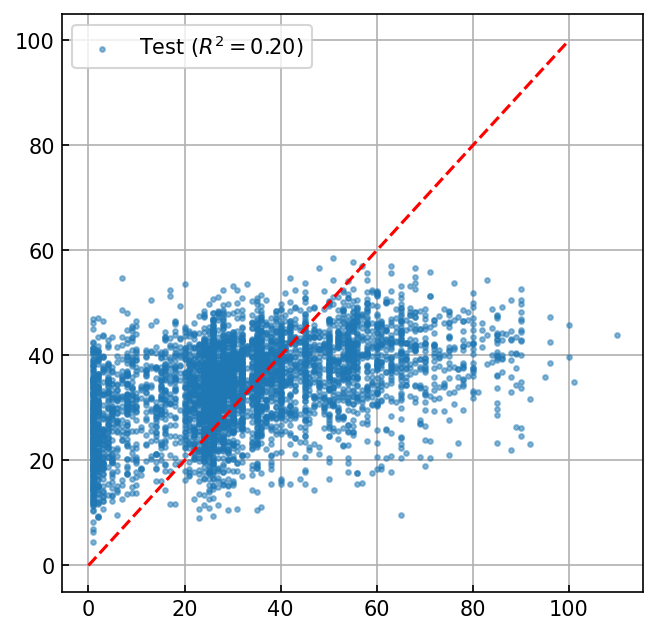

In [99]:
y_true, y_pred = [], []
model.eval()

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)
with torch.no_grad():
    for xb, yb in tqdm(test_loader):
        yp = model(xb.to(device))
        y_true.append(yb.numpy())
        y_pred.append(yp.squeeze().cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

from sklearn.metrics import r2_score
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(y_true, y_pred, s=5, alpha=0.5, label=f'Test ($R^2 = {r2_score(y_true, y_pred):.2f}$)')
ax.plot([0,100], [0, 100], color='red', linestyle='--')
ax.legend();

print(f'Mean absolute difference: {np.mean(np.abs(y_true - y_pred)):.1f} yrs')

In [101]:
import torch.nn as nn
import torch.nn.functional as F

class GaussianNLLLoss(nn.Module):
    def forward(self, inputs, targets):
        means, variances = inputs
        return F.gaussian_nll_loss(means, targets, variances)

class CNN_Regression(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = ConvBlock(3, 32, kernel_size=3, padding='same')
        self.conv2 = ConvBlock(32, 64, kernel_size=3, padding='same')
        self.conv3 = ConvBlock(64, 128, kernel_size=3, padding='same')
        self.conv4 = ConvBlock(128, 256, kernel_size=3, padding='same')
        
        self.fc1 = nn.Linear(256, 512)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        # x has shape [B, 3, H, W]
        x = self.conv1(x) #[B, 32, H/2, W/2]
        x = self.conv2(x) #[B, 64, H/4, W/4]
        x = self.conv3(x) #[B, 128, H/8, W/8]
        x = self.conv4(x) #[B, 256, H/16, W/16]

        # Consider transposing the data
        x = x.permute(0, 2, 3, 1) # Now features is the last dimension
        
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        x_mean = F.relu(x[..., 0:1]) # Prediction for age
        x_logvar = x[..., 1:2] # Local variance/uncertainty

        # Reparameterization trick
        if self.training:
            noise = torch.randn_like(x_mean)
            x_mean = x_mean + noise * (0.5 * x_logvar).exp()

        # Inverse-variance weighted estimate
        weight = (-x_logvar).exp()
        norm = torch.sum(weight, dim=(1, 2)) + 1e-6
        mu = torch.sum(x_mean * weight, dim=(1, 2)) / norm
        var = 1. / norm
        return mu, var

model = CNN_Regression()
loss = GaussianNLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_loss, train_mad, val_loss, val_mad = train(
    model, optimizer, loss, train_dataset, val_dataset,
    batch_size=32, num_epochs=5, num_workers=4)

Epoch 1 | Train loss 1119.516 | Train MAD 39.524 years | Val loss 3.569 | Val MAD 15.536 years 


Epoch 2 | Train loss 4.140 | Train MAD 24.029 years | Val loss 3.534 | Val MAD 15.953 years 


Epoch 3 | Train loss 4.110 | Train MAD 23.728 years | Val loss 3.473 | Val MAD 15.412 years 


Epoch 4 | Train loss 4.107 | Train MAD 23.407 years | Val loss 3.456 | Val MAD 15.339 years 


Epoch 5 | Train loss 4.029 | Train MAD 22.770 years | Val loss 3.416 | Val MAD 15.264 years 


100%|██████████| 151/151 [00:05<00:00, 28.00it/s]

Mean absolute difference: 15.0 yrs


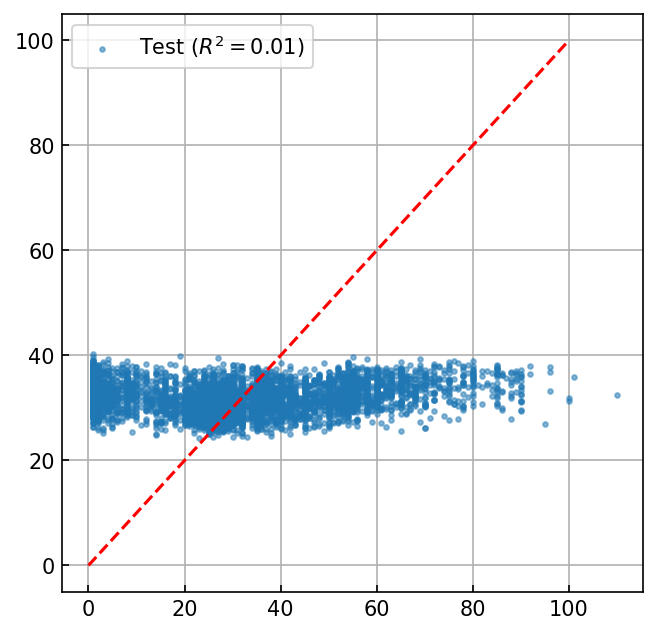

In [102]:
y_true, y_pred = [], []
model.eval()

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)
with torch.no_grad():
    for xb, yb in tqdm(test_loader):
        yp, _ = model(xb.to(device))
        y_true.append(yb.numpy())
        y_pred.append(yp.squeeze().cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

from sklearn.metrics import r2_score
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(y_true, y_pred, s=5, alpha=0.5, label=f'Test ($R^2 = {r2_score(y_true, y_pred):.2f}$)')
ax.plot([0,100], [0, 100], color='red', linestyle='--')
ax.legend();

print(f'Mean absolute difference: {np.mean(np.abs(y_true - y_pred)):.1f} yrs')

In [106]:
import torch.nn as nn
import torch.nn.functional as F

class CNN_Regression(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = ConvBlock(3, 32, kernel_size=3, padding='same')
        self.conv2 = ConvBlock(32, 64, kernel_size=3, padding='same')
        self.conv3 = ConvBlock(64, 128, kernel_size=3, padding='same')
        self.conv4 = ConvBlock(128, 256, kernel_size=3, padding='same')
        
        self.fc1 = nn.Linear(256, 512)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(512, 1)

    def forward(self, x):
        # x has shape [B, 3, H, W]
        x = self.conv1(x) #[B, 32, H/2, W/2]
        x = self.conv2(x) #[B, 64, H/4, W/4]
        x = self.conv3(x) #[B, 128, H/8, W/8]
        x = self.conv4(x) #[B, 256, H/16, W/16]

        # Global max pooling
        x = torch.amax(x, dim=(-1, -2))
        
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return F.relu(x)

model = CNN_Regression()
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss, train_mad, val_loss, val_mad = train(
    model, optimizer, loss, train_dataset, val_dataset,
    batch_size=32, num_epochs=5, num_workers=4)

Epoch 1 | Train loss 513.596 | Train MAD 17.003 years | Val loss 377.743 | Val MAD 14.909 years 


Epoch 2 | Train loss 384.443 | Train MAD 15.051 years | Val loss 372.310 | Val MAD 14.126 years 


Epoch 3 | Train loss 350.185 | Train MAD 14.304 years | Val loss 337.388 | Val MAD 13.737 years 


Epoch 4 | Train loss 329.227 | Train MAD 13.824 years | Val loss 309.780 | Val MAD 13.667 years 


Epoch 5 | Train loss 291.087 | Train MAD 12.969 years | Val loss 270.887 | Val MAD 12.408 years 


100%|██████████| 151/151 [00:05<00:00, 26.27it/s]


Mean absolute difference: 12.1 yrs


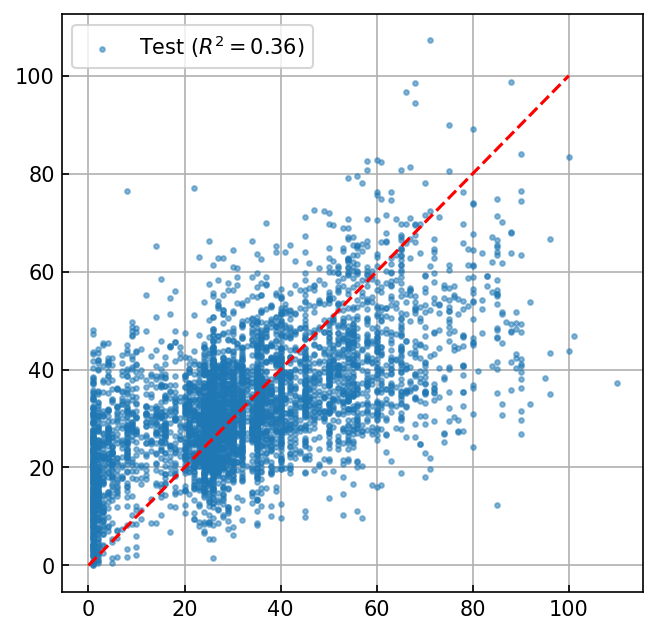

In [107]:
y_true, y_pred = [], []
model.eval()

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)
with torch.no_grad():
    for xb, yb in tqdm(test_loader):
        yp = model(xb.to(device))
        y_true.append(yb.numpy())
        y_pred.append(yp.squeeze().cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

from sklearn.metrics import r2_score
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(y_true, y_pred, s=5, alpha=0.5, label=f'Test ($R^2 = {r2_score(y_true, y_pred):.2f}$)')
ax.plot([0,100], [0, 100], color='red', linestyle='--')
ax.legend();

print(f'Mean absolute difference: {np.mean(np.abs(y_true - y_pred)):.1f} yrs')

In [108]:
model

CNN_Regression(
  (conv1): ConvBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  )
  (conv2): ConvBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  )
  (conv3): ConvBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  )
  (conv4): ConvBlock(
    (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (conv3): Conv2d(256, 256,